# Evaluación final en Test Set

Este notebook se ejecuta **al final del pipeline**, después de:

- `nb02` — tuning de modelos individuales y comparación en validation. Random Forest fue el ganador.
- `nb03` — ensamble por votación, evaluado en validation. **No mejora a RF base**, se descarta.
- `nb04` — calibración (sigmoid e isotonic) sobre RF, evaluada en validation. **No mejora a RF base**, se descarta.

Como ni el ensamble ni la calibración superan al Random Forest base en val, el modelo final es directamente **`random_forest_tuned.pkl`** (del nb02). Acá lo evaluamos **una sola vez** sobre el holdout de test (`X_test`, `y_test`), que no fue tocado en ninguna etapa previa.

In [6]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, fbeta_score, recall_score, precision_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
)

import warnings
warnings.filterwarnings('ignore')

BETA = 2
METRIC_NAME = f'F{BETA}'

# Datos: solo necesitamos el holdout de test
data = joblib.load('../data/processed_data.pkl')
X_test = data['X_test']
y_test = data['y_test']

# Modelo final = Random Forest base (ganó en val, ni ensamble ni calibración mejoraron)
final_model = joblib.load('../models/random_forest_tuned.pkl')
final_name  = 'Random Forest'

# Métricas en val del ganador (de tuning_results.pkl que guarda el nb02)
tuning_results = joblib.load('../data/tuning_results.pkl')
val_results    = tuning_results['val_results']
val_metrics_winner = val_results.loc[final_name].to_dict()

print(f'Modelo final: {final_name}')
print(f'X_test shape: {X_test.shape}')

Modelo final: Random Forest
X_test shape: (1022, 14)


## Métricas en test

In [7]:
y_pred_test = final_model.predict(X_test)
y_prob_test = final_model.predict_proba(X_test)[:, 1] if hasattr(final_model, 'predict_proba') else None

test_metrics = {
    'F1':        f1_score(y_test, y_pred_test, zero_division=0),
    METRIC_NAME: fbeta_score(y_test, y_pred_test, beta=BETA, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_test, zero_division=0),
    'Precision': precision_score(y_test, y_pred_test, zero_division=0),
}
if y_prob_test is not None:
    test_metrics['AUC-ROC'] = roc_auc_score(y_test, y_prob_test)
    test_metrics['PR-AUC']  = average_precision_score(y_test, y_prob_test)

test_df = pd.DataFrame([test_metrics], index=[final_name])
display(test_df.style.format('{:.4f}'))

,F1,F2,Recall,Precision,AUC-ROC,PR-AUC
Random Forest,0.2492,0.4176,0.7600,0.1490,0.8285,0.1937


## Comparación val vs test

Comparamos las métricas del ganador en validation (donde se eligió) contra test (holdout no tocado). Si las diferencias son chicas, el modelo generaliza bien y no hubo overfitting al val set.

In [8]:
comparison = pd.DataFrame({
    'Val (selección)':      pd.Series(val_metrics_winner),
    'Test (holdout final)': pd.Series(test_metrics),
})
comparison['Δ (test - val)'] = comparison['Test (holdout final)'] - comparison['Val (selección)']
display(comparison.style.format('{:.4f}'))

,Val (selección),Test (holdout final),Δ (test - val)
AUC-ROC,0.8071,0.8285,0.0214
F1,0.2458,0.2492,0.0033
F2,0.4102,0.4176,0.0074
PR-AUC,0.2589,0.1937,-0.0652
Precision,0.1474,0.1490,0.0016
Recall,0.7400,0.7600,0.0200


## Curvas ROC y Precision-Recall en test

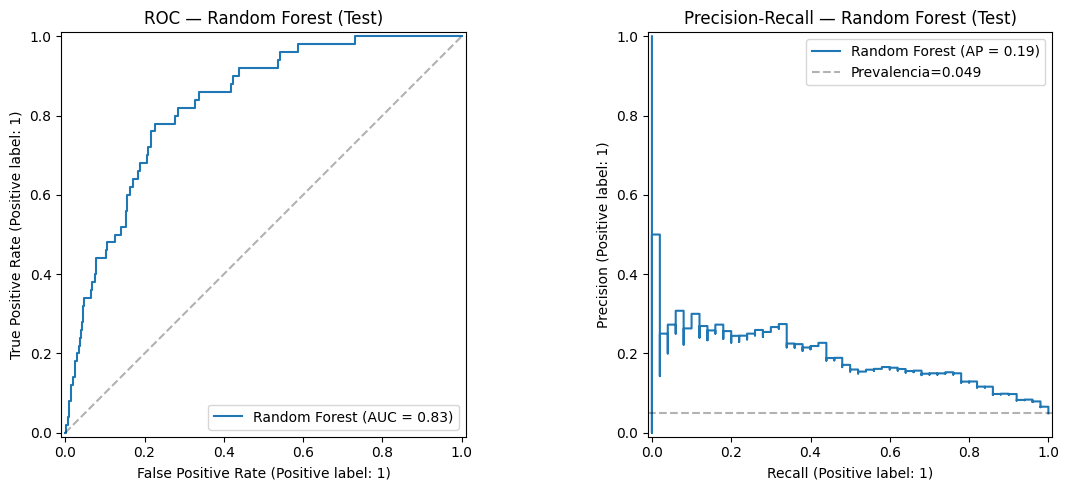

In [9]:
if y_prob_test is not None:
    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5))

    RocCurveDisplay.from_predictions(y_test, y_prob_test, name=final_name, ax=ax_roc)
    ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax_roc.set_title(f'ROC — {final_name} (Test)')

    PrecisionRecallDisplay.from_predictions(y_test, y_prob_test, name=final_name, ax=ax_pr)
    prevalence_test = y_test.mean() if hasattr(y_test, 'mean') else np.mean(y_test)
    ax_pr.axhline(prevalence_test, color='k', linestyle='--', alpha=0.3,
                  label=f'Prevalencia={prevalence_test:.3f}')
    ax_pr.legend(loc='upper right')
    ax_pr.set_title(f'Precision-Recall — {final_name} (Test)')

    plt.tight_layout()
    plt.show()
else:
    print('El modelo final no expone predict_proba; se omite ROC/PR.')

## Matriz de confusión en test

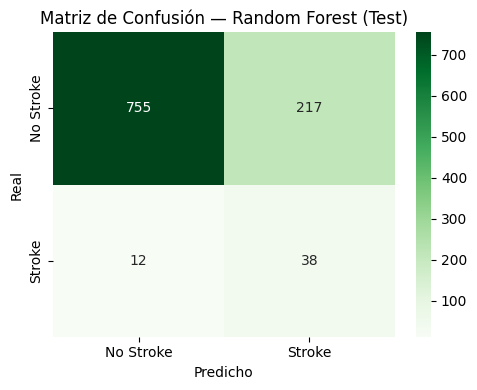

In [10]:
cm_test = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title(f'Matriz de Confusión — {final_name} (Test)')
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.tight_layout()
plt.show()

## Conclusiones


**Elección de la métrica F2​: Priorización del Recall**

Dado que se trabajó sobre la predicción de infartos cerebrales (stroke), el costo de un Falso Negativo (no detectar a un paciente en riesgo) es mucho más grave que  un Falso Positivo que tiene consecuencias menores. Se seleccionó la métrica F2​ porque otorga mayor peso al Recall que a la Precisión, con la idea de que el modelo sea capaz de identificar la mayor cantidad de ACVs. Esto genera algunas falsas alarmas, pero se prioriza la mayor cobertura en la detección.

**Validación vs Test**  

El modelo demuestra gran capacidad de generalización. Si se comparan los resultados del conjunto de validación (usado para la selección) contra el conjunto de prueba las métricas muestran:

-El F2​ subió ligeramente de 0.4102 a 0.4176.  
-El Recall mejoró del 74% al 76% en el test set.  
-El AUC-ROC aumentó de 0.8071 a 0.8285. Estas diferencias positivas indican que no hubo sobreajuste (overfitting) y que el modelo mantiene su eficacia ante datos totalmente nuevos.  
  
    
**Matriz de Confusión**  
  
La matriz de confusión en en test, muestra la característica "preventiva" del modelo:

   Sensibilidad: Logró identificar correctamente 38 de 50 casos reales de infarto.  
   Falsos Negativos mínimos: Solo se omitieron 12 casos, minimizando el riesgo de dejar pacientes críticos sin atención.  
   Costo de la precisión: Se generaron 217 falsos positivos y 755 verdaderos negativos. Esto baja la precisión a 14.9%, pero es un aceptable bajo el criterio de diseño F2​ para no perder casos positivos en una clase tan minoritaria (4.9% de prevalencia).  

**Interpretación de Curvas ROC y Precision-Recall**

Curva ROC: El AUC de 0.83 indica alta capacidad para clasificar ambas clases. 

Curva Precision-Recall: Con un Average Precision (AP) de 0.19, el modelo está por encima de la línea de prevalencia base (0.049). Esto indica que a pesar del extremo desbalance de datos el modelo aporta un valor predictivo real en comparación con el azar.



**Selección de Random Forest sobre Ensambles**


A pesar de evaluar distintos modelos alternativos, se optó por el Random Forest debido a la superioridad en validación ya que ni los ensambles por votación (VotingClassifier) ni las técnicas de calibración (Sigmoid/Isotonic) lograron superar el F2​ del Random Forest individual en la fase de validación.

El Random Forest identificó eficazmente las relaciones no lineales del dataset (como la fuerte influencia de la edad) sin el sobreajuste se obtuvo en boosting. Por otro lado también fue mucho más simple que los ensambles, que no aportaron una ganancia marginal significativa



**Variables influyentes**


En base al EDA y el análisis realizado, las variables más influyentes para el modelo Random Forest son las siguientes:

Edad (Age): Es la variable más influyente. Los análisis de correlación (Pearson, Spearman y Point-biserial) la identificaron como el feature más relevante del dataset para predecir ACVs. De hecho, hasta en el modelo básico (baseline) que solo utilizaba la edad para predecir (age > 50) predecía el 82% de los casos de stroke.

Otros antedecentes médicos(Heart Disease e Hypertension): Estos features mostraron una relación significativa con la ocurrencia de infartos. El análisis de Cramér's V las asoció como las variables categóricas más correlacionadas con el target.

Nivel de Glucosa (Avg Glucose Level): Obtuvo una asociación moderada con el stroke. Los pacientes con stroke suelen tener niveles de glucosa más elevados en comparación con los que no lo tuvieron.

Por otro lado, features como el BMI mostraron una predicción muy baja de forma individual, y factores demográficos como el género (gender) o el tipo de residencia (Residence_type) no presentaron correlaciones significativas con el riesgo de infarto